In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

from scipy.stats import kruskal
from src.pipeline import run_etl
from src.pipeline import DOMINIOS, DC_LABELS, EDUCATION_LEVEL, DC_LABELS, DC_ORDER

In [3]:
df_tabla_0_imp, df_tabla_1_imp, df_complete = run_etl(dotenv_path="../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

 Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida       

In [9]:
df_complete.isnull().sum()

sheet_name        0
nivel_estudio     0
dc                0
orientacion       0
atencion          0
lenguaje          0
memoria_verbal    0
memoria_visual    0
gnosias           0
praxis            0
ejecutivas        0
age_num           0
dtype: int64

In [ ]:
#Configuraciones para las gráficas
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110})

DC_PALETTE = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
DOMINIOS_COGNITIVOS = list(DOMINIOS.keys())

In [11]:
df_complete.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sheet_name,117,117,GC1-60,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nivel_estudio,117.0,NaN,NaN,NaN,0.692308,0.463524,0.0,0.0,1.0,1.0,1.0
dc,117.0,NaN,NaN,NaN,1.042735,0.711884,0.0,1.0,1.0,2.0,2.0
orientacion,117.0,NaN,NaN,NaN,2.849003,0.935154,1.0,2.333333,3.0,4.0,4.0
atencion,117.0,NaN,NaN,NaN,2.817664,0.378722,1.666667,2.666667,3.0,3.0,3.666667
lenguaje,117.0,NaN,NaN,NaN,3.341168,0.547874,2.0,3.0,3.5,3.75,4.0
memoria_verbal,117.0,NaN,NaN,NaN,2.578632,0.436844,1.0,2.25,2.6,3.0,4.0
memoria_visual,117.0,NaN,NaN,NaN,2.740741,0.424605,1.0,2.666667,2.666667,3.0,4.0
gnosias,117.0,NaN,NaN,NaN,3.495726,0.726635,2.0,3.0,4.0,4.0,4.0
praxis,117.0,NaN,NaN,NaN,3.089744,0.641978,1.0,2.5,3.0,3.5,4.0


## Distribución de edad

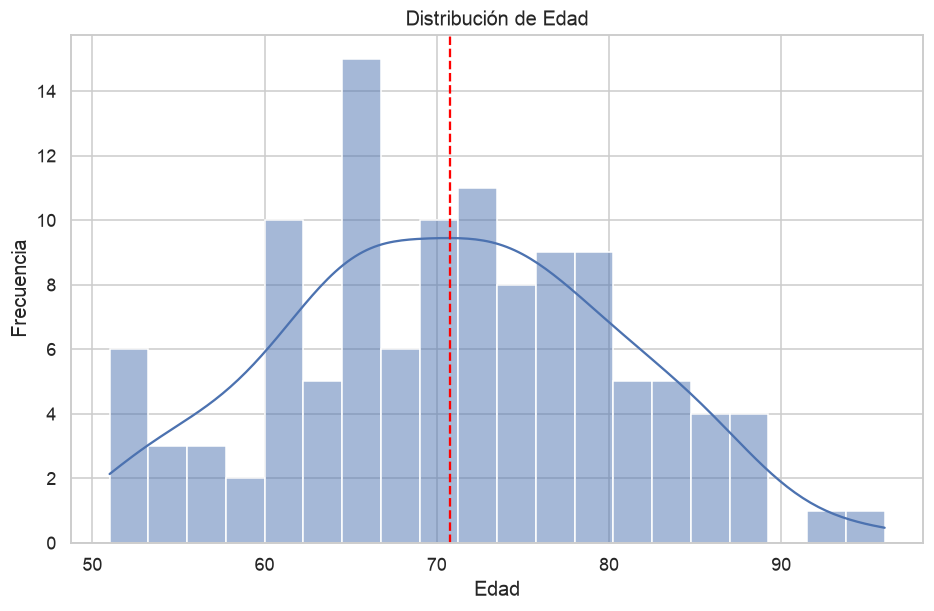

In [ ]:
#Distribución de edad general de toda la población
plt.figure(figsize=(10, 6))
sns.histplot(data=df_complete, x="age_num", palette=DC_PALETTE, bins=20, kde=True)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
## Linea vertical para la media
plt.axvline(df_complete["age_num"].mean(), color="red", linestyle="--", label="Media")
plt.show()

## Distribución del nivel de estudio

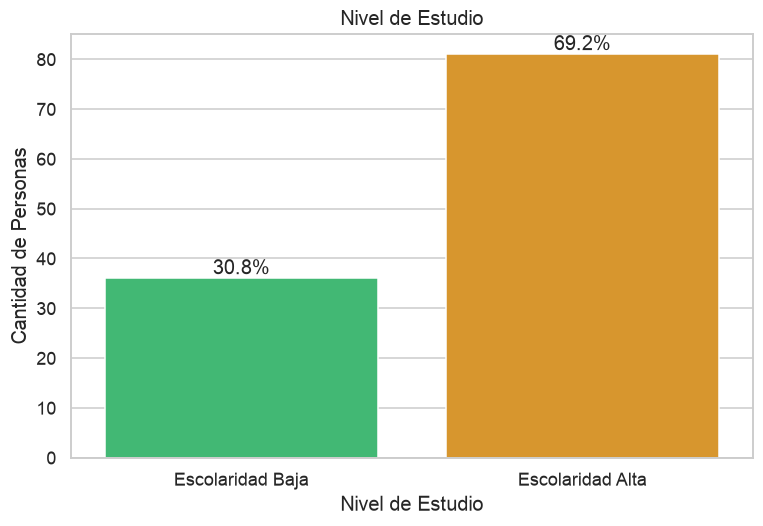

In [13]:
# Nivel de estudio de todo el dataset
plt.figure(figsize=(8, 5))
boxes = sns.countplot(data=df_complete, x="nivel_estudio", palette=[DC_PALETTE[0], DC_PALETTE[1]])
#añadir el porcentaje encima de cada barra
for p in boxes.patches:
    height = p.get_height()
    percentage = f"{(height / len(df_complete) * 100):.1f}%"
    boxes.annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha="center", va="bottom")
plt.title("Nivel de Estudio")
plt.xlabel("Nivel de Estudio")
plt.ylabel("Cantidad de Personas")
plt.xticks(ticks=[0, 1], labels=["Escolaridad Baja", "Escolaridad Alta"])
plt.show()


## Distribución de los dominios cognitivos

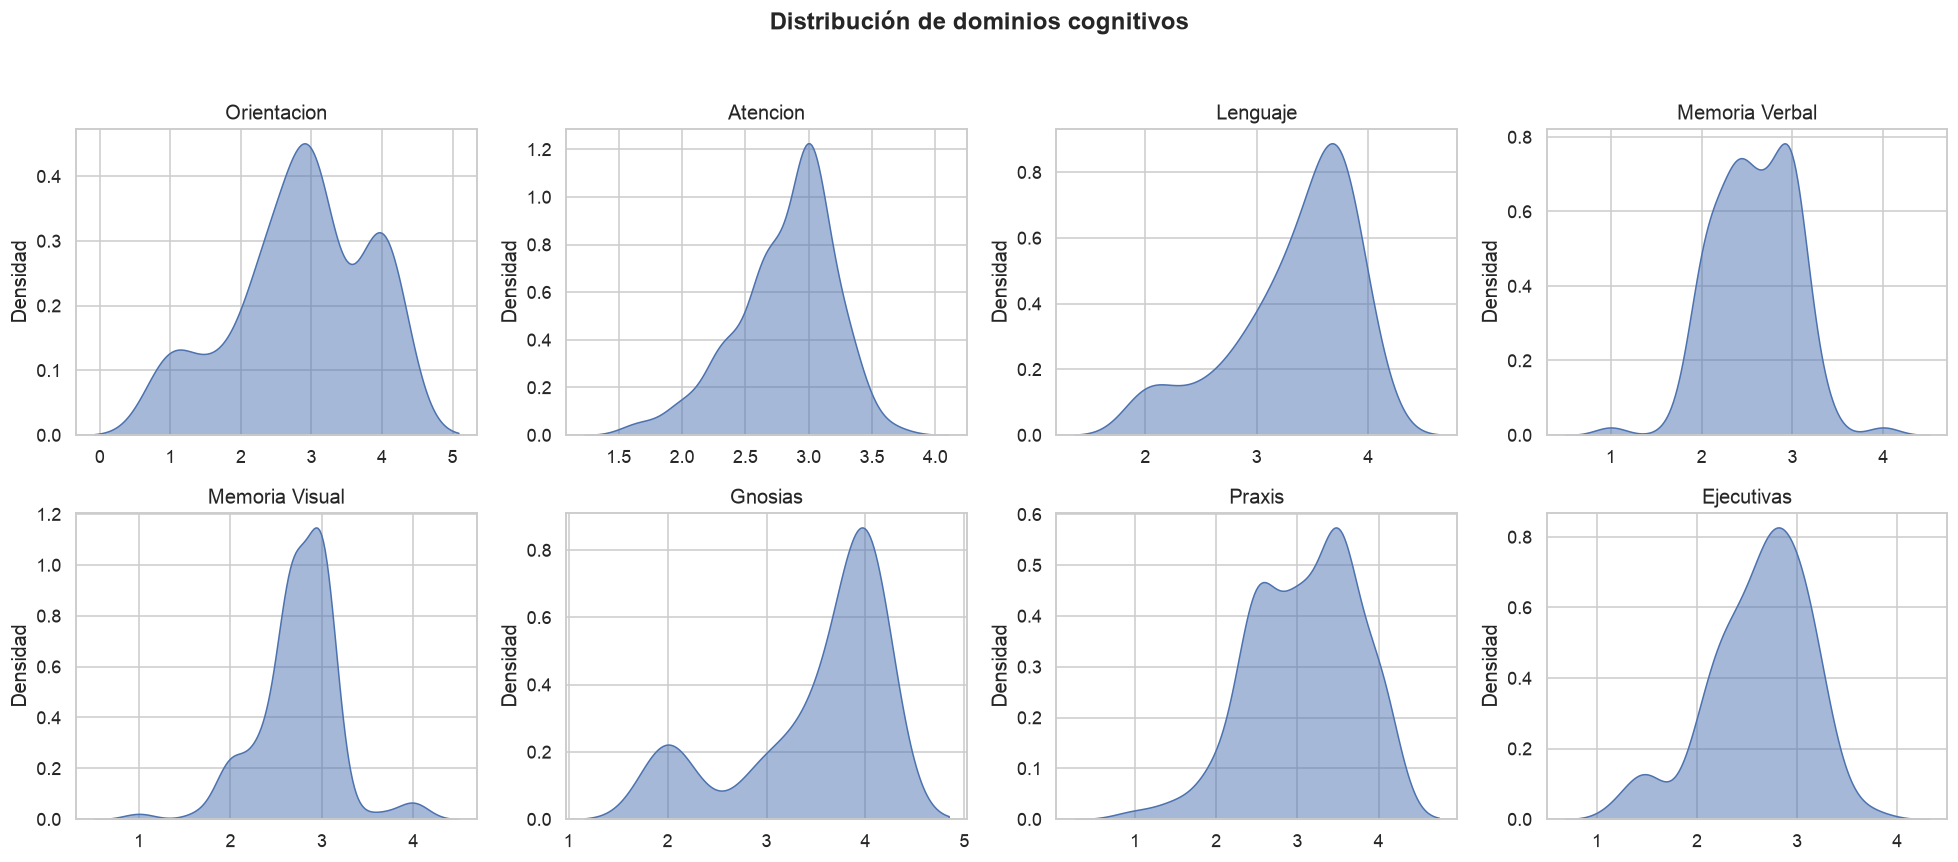

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

fig.suptitle(
    "Distribución de dominios cognitivos",
    fontsize=16,
    fontweight="bold"
)


## Distribución de cada dominio cognitivo
for ax, dominio in zip(axes.flatten(), DOMINIOS):

    sns.kdeplot(
        data=df_complete,
        x=dominio,
        fill=True,
        alpha=0.5,
        ax=ax
    )

    ax.set_title(dominio.replace('_', ' ').title())

    ax.set_xlabel("")

    ax.set_ylabel("Densidad")

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

## Distribución de deterioro cognitivo en la muestra

(0.0, 72.5)

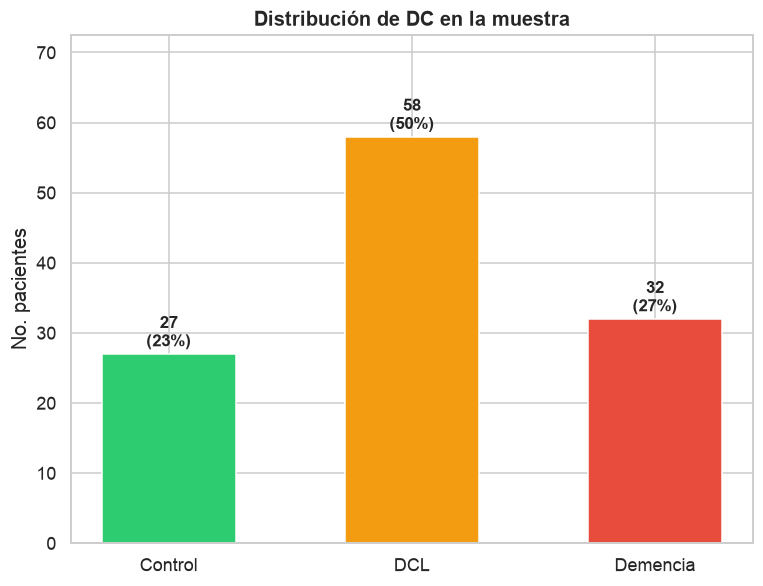

In [15]:
fig = plt.figure(figsize=(8, 6))

# GRÁFICO DE DISTRIBUCIÓN DE LOS DATOS
counts = df_complete["dc"].value_counts().sort_index()
x_pos = list(range(len(DC_ORDER)))
bars = plt.bar(
    x_pos,
    [counts.get(k, 0) for k in DC_ORDER],
    color=DC_PALETTE.values(),
    edgecolor="white", width=0.55,
)
for bar, k in zip(bars, DC_ORDER):
    v   = counts.get(k, 0)
    pct = v / len(df_complete) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{v}\n({pct:.0f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
plt.xticks(ticks=x_pos, labels=[DC_LABELS[k] for k in DC_ORDER])
plt.ylabel("No. pacientes")
plt.title("Distribución de DC en la muestra", fontweight="bold")
plt.ylim(0, counts.max() * 1.25)

## Distribución de edad por grupo clinico

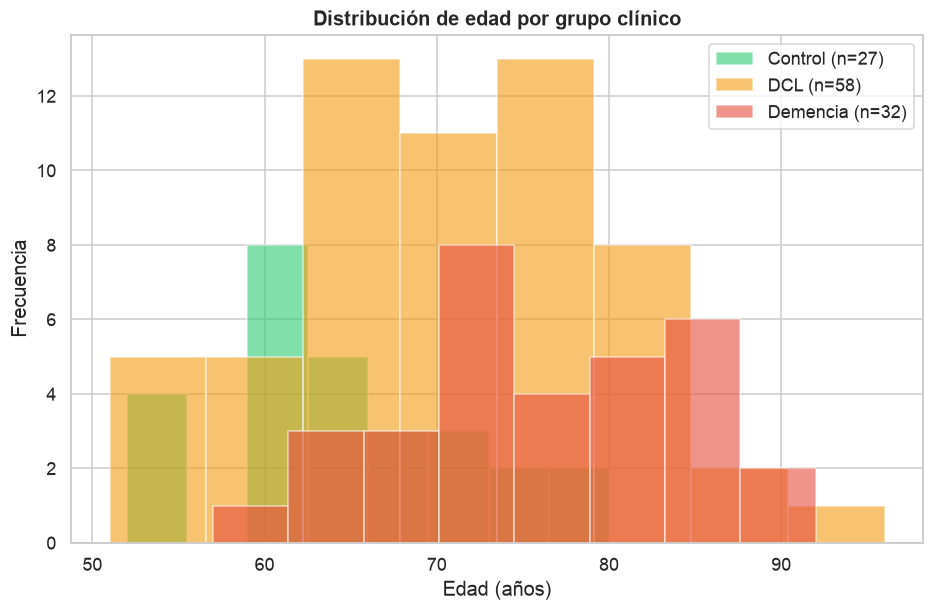


Edad por grupo
     n   media    std  min  max  dc_label
dc                                       
0   27  64.556  7.723   52   80   Control
1   58  70.603  9.514   51   96       DCL
2   32  76.219  8.435   57   92  Demencia


In [16]:
plt.figure(figsize=(10, 6))
for dc_val in DC_ORDER:
    subset = df_complete[df_complete["dc"] == dc_val]["age_num"].dropna()
    plt.hist(subset, bins=8, alpha=0.6, color=DC_PALETTE[dc_val], label=f"{DC_LABELS[dc_val]} (n={len(subset)})", edgecolor="white")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")
plt.title("Distribución de edad por grupo clínico", fontweight="bold")
plt.legend()
plt.show()


# Tabla de estadísticos de edad
print("\nEdad por grupo")
print(
    df_complete.groupby("dc")["age_num"]
    .agg(n="count", media="mean", std="std", min="min", max="max")
    .assign(dc_label=lambda x: x.index.astype(int).map(DC_LABELS))
    .round(3)
)

## Distribución de nivel de estudio por grupo clinico

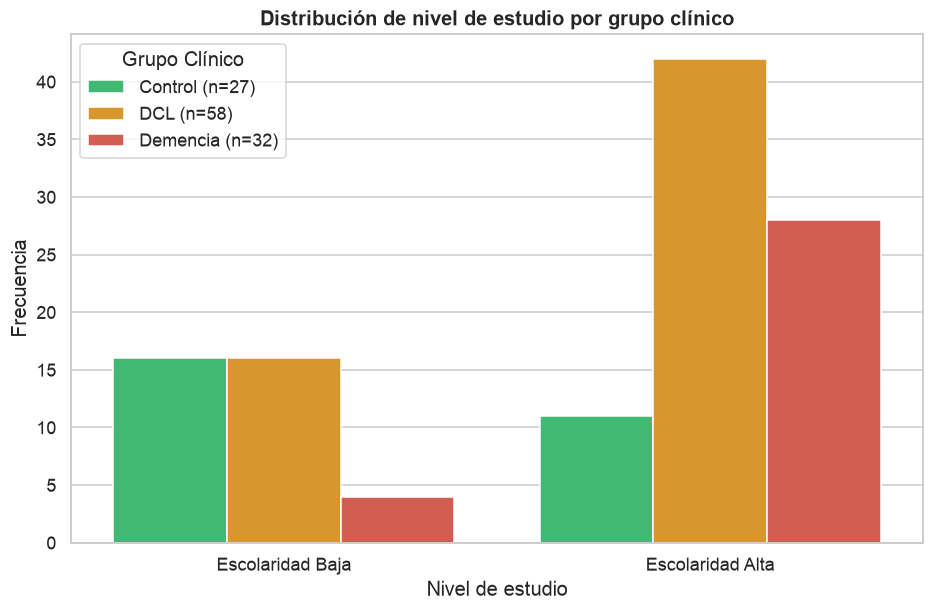

In [ ]:
plt.figure(figsize=(10, 6))

# Seaborn se encarga de agrupar por 'nivel_estudio' y separar por 'dc' (hue)
sns.countplot(
    data=df_complete.dropna(subset=["nivel_estudio"]),
    x="nivel_estudio",
    hue="dc",
    hue_order=DC_ORDER,
    palette=DC_PALETTE,
    edgecolor="white"
)

# Ajustes de etiquetas y títulos
plt.xlabel("Nivel de estudio")
plt.ylabel("Frecuencia")
plt.title("Distribución de nivel de estudio por grupo clínico", fontweight="bold")
#Nivel de estudios segun el map EDUCATION_LEVEL
plt.xticks(ticks=[0, 1], labels=[EDUCATION_LEVEL[k]
              for k in sorted(EDUCATION_LEVEL.keys())])
# Etiquetas
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = [f"{DC_LABELS[int(label)]} (n={len(df_complete[df_complete['dc'] == int(label)])})" for label in labels]
plt.legend(handles, new_labels, title="Grupo Clínico")

plt.show()

## Puntajes por dominio cognitivo

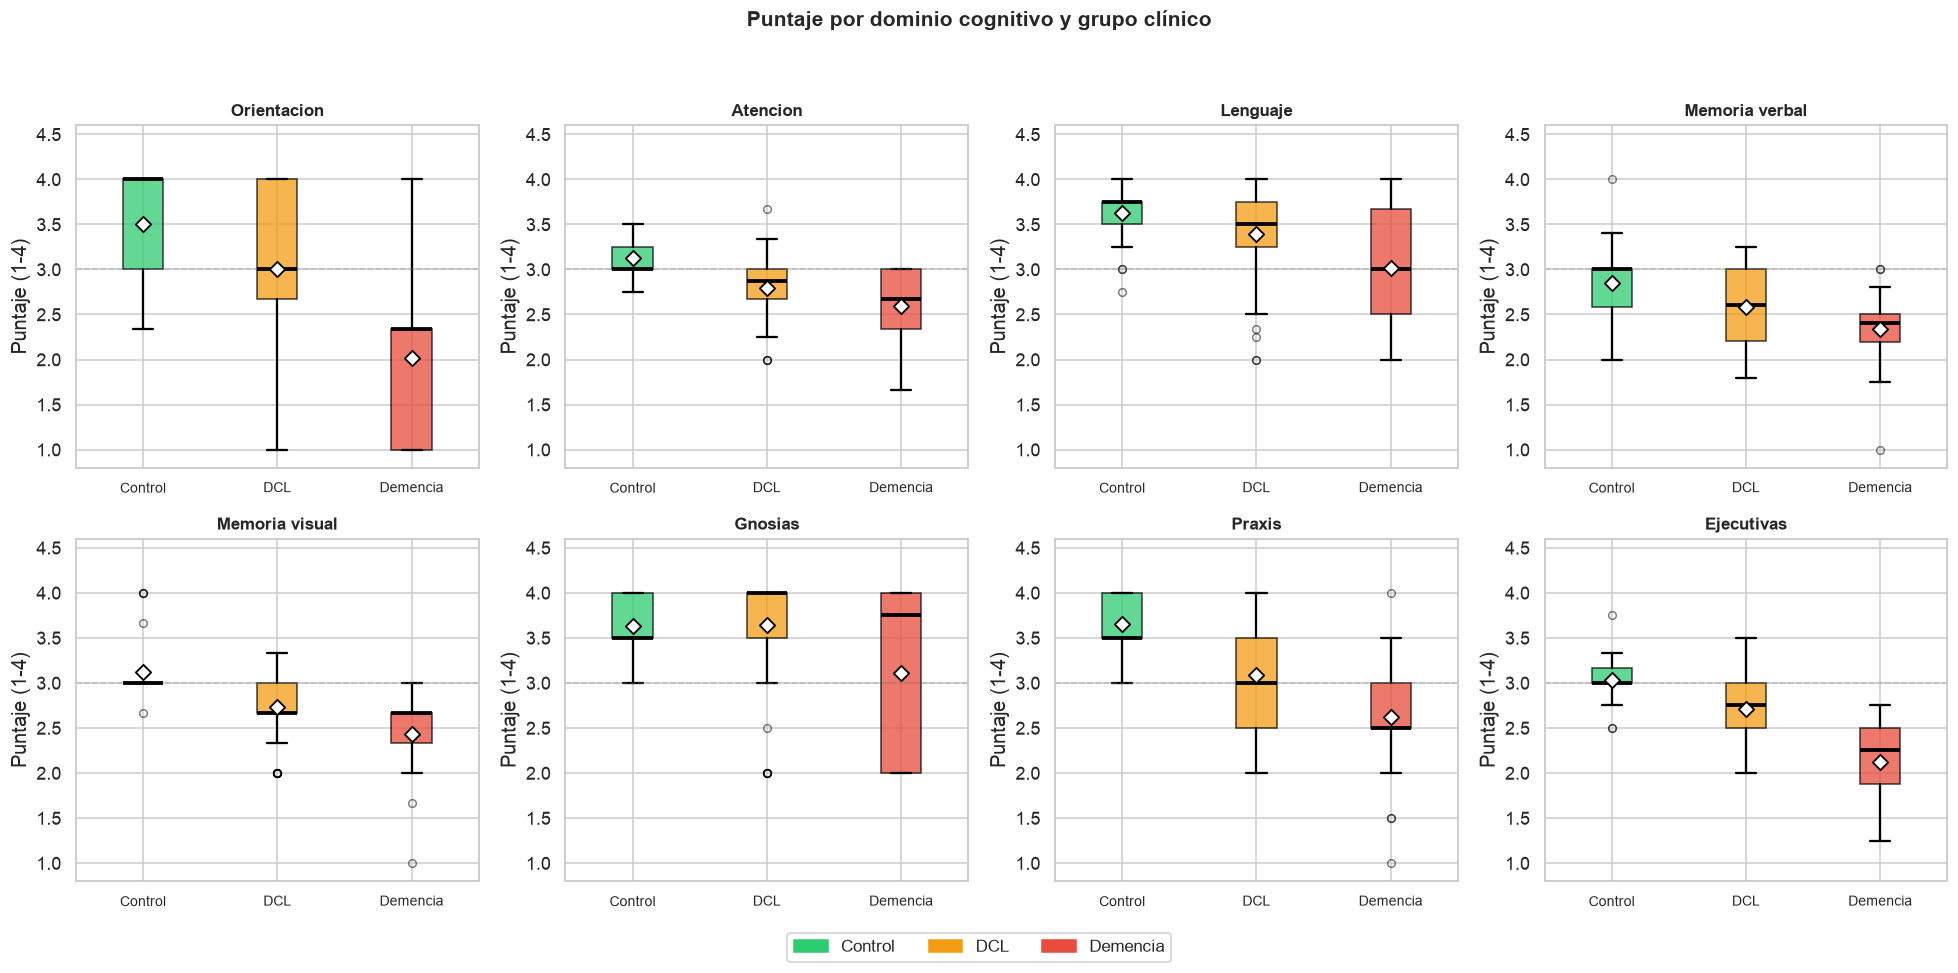

In [ ]:


fig, axes = plt.subplots(2, 4, figsize=(18, 9), squeeze=False)
axes_flat = axes.flatten()

for ax, dominio in zip(axes_flat, DOMINIOS):
    # Extracción de los datos para cada grupo clínico
    data_plot = [
        df_complete[df_complete["dc"] == dc_val][dominio].dropna()
        for dc_val in DC_ORDER
    ]

    # Generación del boxplot
    bp = ax.boxplot(
        data_plot,
        patch_artist=True,
        notch=False,
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=5, alpha=0.5),
    )

    for i, (patch, dc_val, vals) in enumerate(
        zip(bp["boxes"], DC_ORDER, data_plot), 1
    ):
        patch.set_facecolor(DC_PALETTE[dc_val])
        patch.set_alpha(0.75)

        if len(vals) > 0:
            ax.scatter(
                i,
                vals.mean(),
                marker="D",
                s=50,
                color="white",
                edgecolors="black",
                linewidth=1.2,
                zorder=5,
            )

    # Configuración de los ejes
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([DC_LABELS[k] for k in DC_ORDER], fontsize=9)
    ax.set_ylabel("Puntaje (1-4)")
    ax.set_ylim(0.8, 4.6)
    ax.set_title(
        dominio.replace("_", " ").capitalize(), fontweight="bold", fontsize=11
    )
    ax.axhline(3, color="grey", linestyle="--", alpha=0.35, linewidth=1)

for ax in axes_flat[len(DOMINIOS) :]:
    ax.set_visible(False)

# Leyenda y Títulos
handles = [
    mpatches.Patch(color=DC_PALETTE[k], label=DC_LABELS[k]) for k in DC_ORDER
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=11,
    framealpha=0.9,
)
fig.suptitle(
    "Puntaje por dominio cognitivo y grupo clínico",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

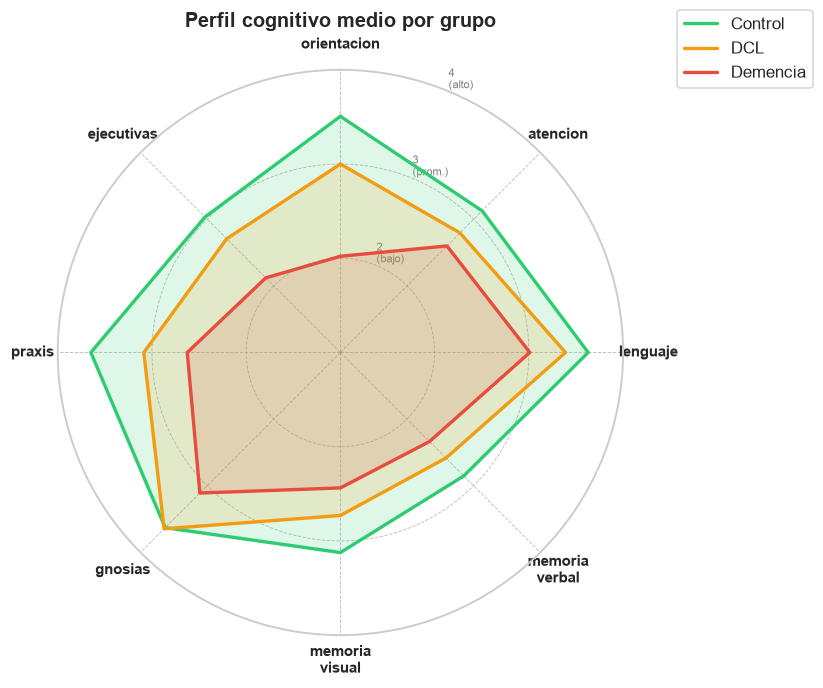

In [ ]:
#Gráfico de radar para visualizar el perfil cognitivo medio por grupo clínico
N = len(DOMINIOS_COGNITIVOS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_closed = angles + angles[:1] 
labels = [d.replace("_", "\n") for d in DOMINIOS_COGNITIVOS]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

for dc_val in DC_ORDER:
    vals = df_complete[df_complete["dc"] == dc_val][DOMINIOS_COGNITIVOS].mean().values
    v_closed = vals.tolist() + [vals[0]]
    ax.plot(angles_closed, v_closed,
            color=DC_PALETTE[dc_val], linewidth=2.2, label=DC_LABELS[dc_val])
    ax.fill(angles_closed, v_closed,
            color=DC_PALETTE[dc_val], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=10, fontweight="bold")
ax.set_ylim(1, 4)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1\n(alt. sev.)", "2\n(bajo)", "3\n(prom.)", "4\n(alto)"],
                   fontsize=7, color="grey")
ax.grid(color="grey", linestyle="--", linewidth=0.6, alpha=0.5)
ax.set_title("Perfil cognitivo medio por grupo",
             fontsize=13, fontweight="bold", pad=28)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=11)
plt.tight_layout()
plt.show()

# Correlaciones entre dominios cognitivos

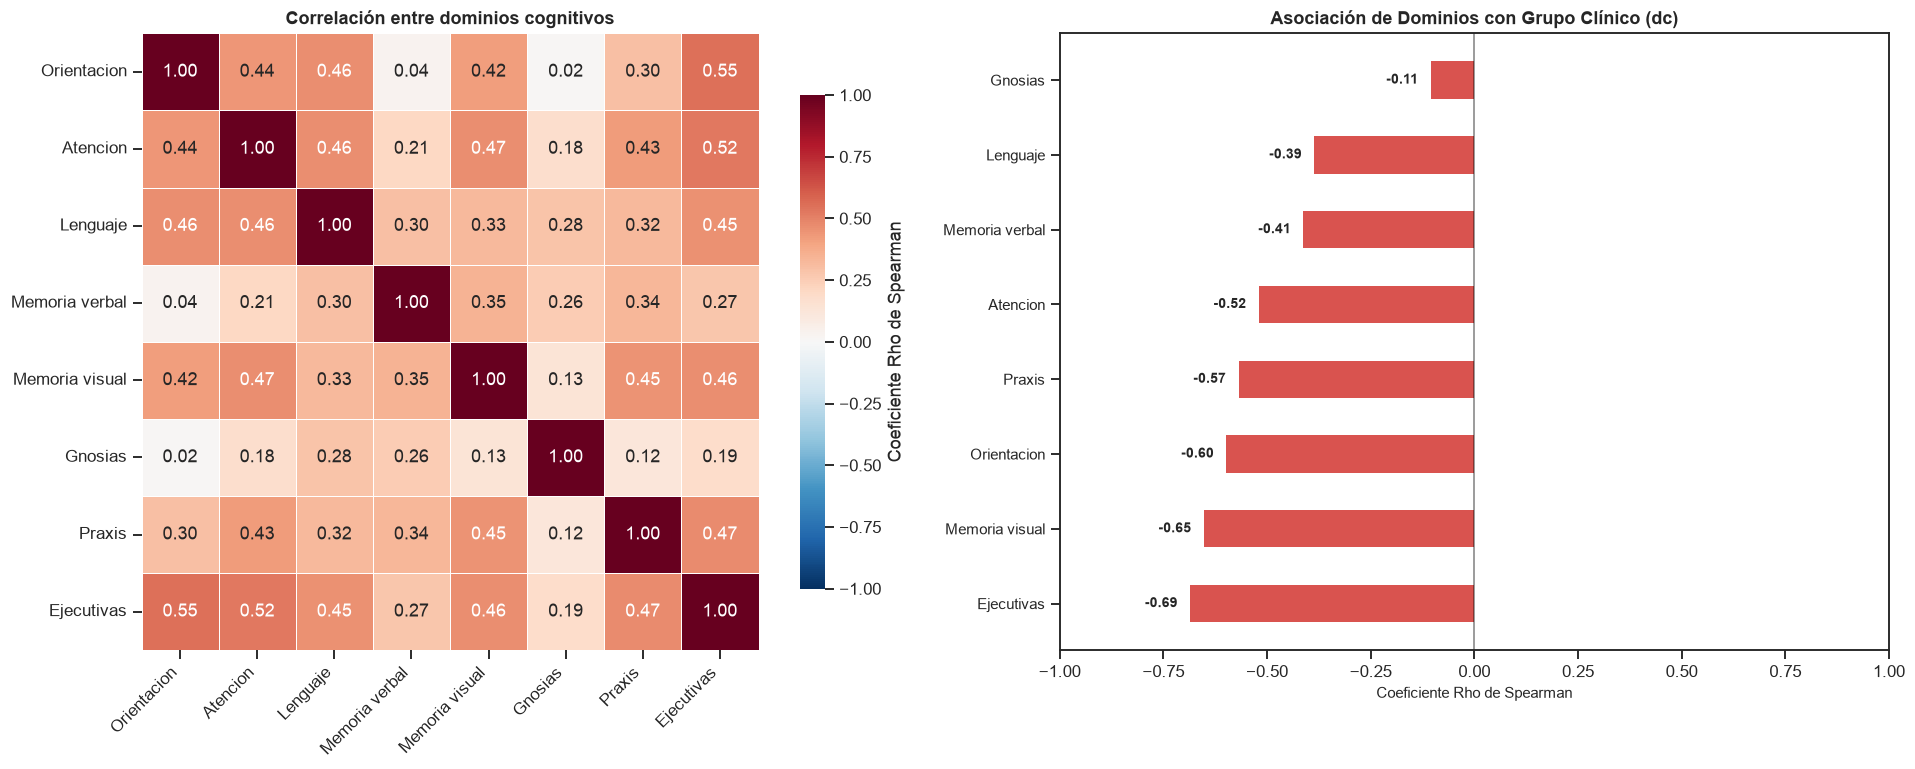

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), squeeze=False)
ax_left, ax_right = axes[0, 0], axes[0, 1]

# mapa de calor de correlación entre dominios cognitivos
corr_dom = df_complete[DOMINIOS_COGNITIVOS].corr(method="spearman")

sns.heatmap(
    corr_dom,
    ax=ax_left,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Coeficiente Rho de Spearman"},
)
# formatear las etiquetas
ax_left.set_xticklabels(
    [d.replace("_", " ").capitalize() for d in DOMINIOS_COGNITIVOS],
    rotation=45,
    ha="right",
)
ax_left.set_yticklabels(
    [d.replace("_", " ").capitalize() for d in DOMINIOS_COGNITIVOS], rotation=0
)
ax_left.set_title(
    "Correlación entre dominios cognitivos", fontweight="bold", fontsize=12
)

#Dominios cognitivos vs grupo clínico con Spearman
df_temp = df_complete.copy()
df_temp["dc_num"] = df_temp["dc"].map(dc_mapping)

# Calcular correlación usando la nueva columna numérica
corr_dc = (
    df_temp[DOMINIOS_COGNITIVOS + ["dc_num"]]
    .corr(method="spearman")[["dc_num"]]
    .drop("dc_num")
    .sort_values("dc_num")
)

dom_names = corr_dc.index.tolist()
rho_vals = corr_dc["dc_num"].values.tolist()
y_pos = list(range(len(dom_names)))

bar_colors = ["#d9534f" if v < 0 else "#5cb85c" for v in rho_vals]

# barras horizontales
ax_right.barh(y_pos, rho_vals, color=bar_colors, edgecolor="none", height=0.5)
ax_right.set_yticks(y_pos)

# nombres de los dominios
ax_right.set_yticklabels(
    [name.replace("_", " ").capitalize() for name in dom_names], fontsize=10
)

# Eje central de referencia
ax_right.axvline(0, color="black", linewidth=1, linestyle="-", alpha=0.5)
ax_right.set_xlabel("Coeficiente Rho de Spearman", fontsize=10)
ax_right.set_title("Asociación de Dominios con Grupo Clínico (dc)", fontweight="bold", fontsize=12)
ax_right.set_xlim(-1, 1)  # Forzar rango de correlación en el eje X

for i, v in enumerate(rho_vals):
    offset = 0.03 if v >= 0 else -0.03
    ha = "left" if v >= 0 else "right"
    ax_right.text(
        v + offset,
        i,
        f"{v:.2f}",
        va="center",
        ha=ha,
        fontsize=9,
        fontweight="bold",
    )

#mostrar la figura
plt.tight_layout()
plt.show()

Kruskal-Wallis: diferencias entre grupos dc

Dominio                    H    p-value
---------------------------------------------
orientacion           42.835  0.0000000005
atencion              34.231  0.0000000369
lenguaje              17.310  0.0001742189
memoria_verbal        19.748  0.0000514965
memoria_visual        49.730  0.0000000000
gnosias                6.912  0.0315572940
praxis                38.236  0.0000000050
ejecutivas            54.880  0.0000000000
nivel_estudio         15.445  0.0004428247
age_num               21.808  0.0000183869


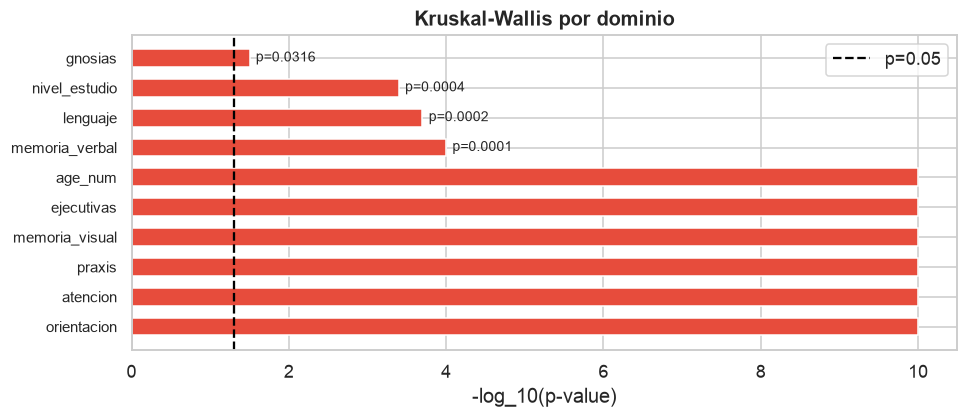

In [21]:
print("Kruskal-Wallis: diferencias entre grupos dc\n")
print(f"{'Dominio':<20} {'H':>7}  {'p-value':>9}")
print("-" * 45)

kw_rows = []
variables = DOMINIOS_COGNITIVOS + ["nivel_estudio", "age_num"]
for dom in variables:
    grupos = [
        df_complete[df_complete["dc"] == k][dom] for k in DC_ORDER
    ]
    grupos_ok = [g for g in grupos if len(g) >= 2]
    if len(grupos_ok) < 2:
        kw_rows.append({"dominio": dom, "H": np.nan, "p": np.nan})
        continue
    H, p = kruskal(*grupos_ok)
    kw_rows.append({"dominio": dom, "H": round(H, 3), "p": round(p, 4)})
    print(f"{dom:<20} {H:>7.3f}  {p:>9.10f}")

# Gráfico de -log10(p)
df_kw = pd.DataFrame(kw_rows).sort_values("p").reset_index(drop=True)
n_kw = len(df_kw)
y_pos = list(range(n_kw))
c_kw = ["#e74c3c" if p < 0.05 else "#95a5a6" for p in df_kw["p"]]
thresh = -np.log10(0.05)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(y_pos, -np.log10(df_kw["p"].clip(lower=1e-10)),
        color=c_kw, edgecolor="white", height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_kw["dominio"].tolist(), fontsize=10)
ax.axvline(thresh, color="black", linestyle="--", linewidth=1.5, label="p=0.05")
ax.set_xlabel("-log_10(p-value)")
ax.set_title("Kruskal-Wallis por dominio",
             fontweight="bold")
ax.legend()

for i, row in df_kw.iterrows():
    x_val = -np.log10(row["p"])
    ax.text(x_val + 0.08, i, f"p={row['p']:.4f}",
            va="center", fontsize=9)

plt.tight_layout()
plt.show()

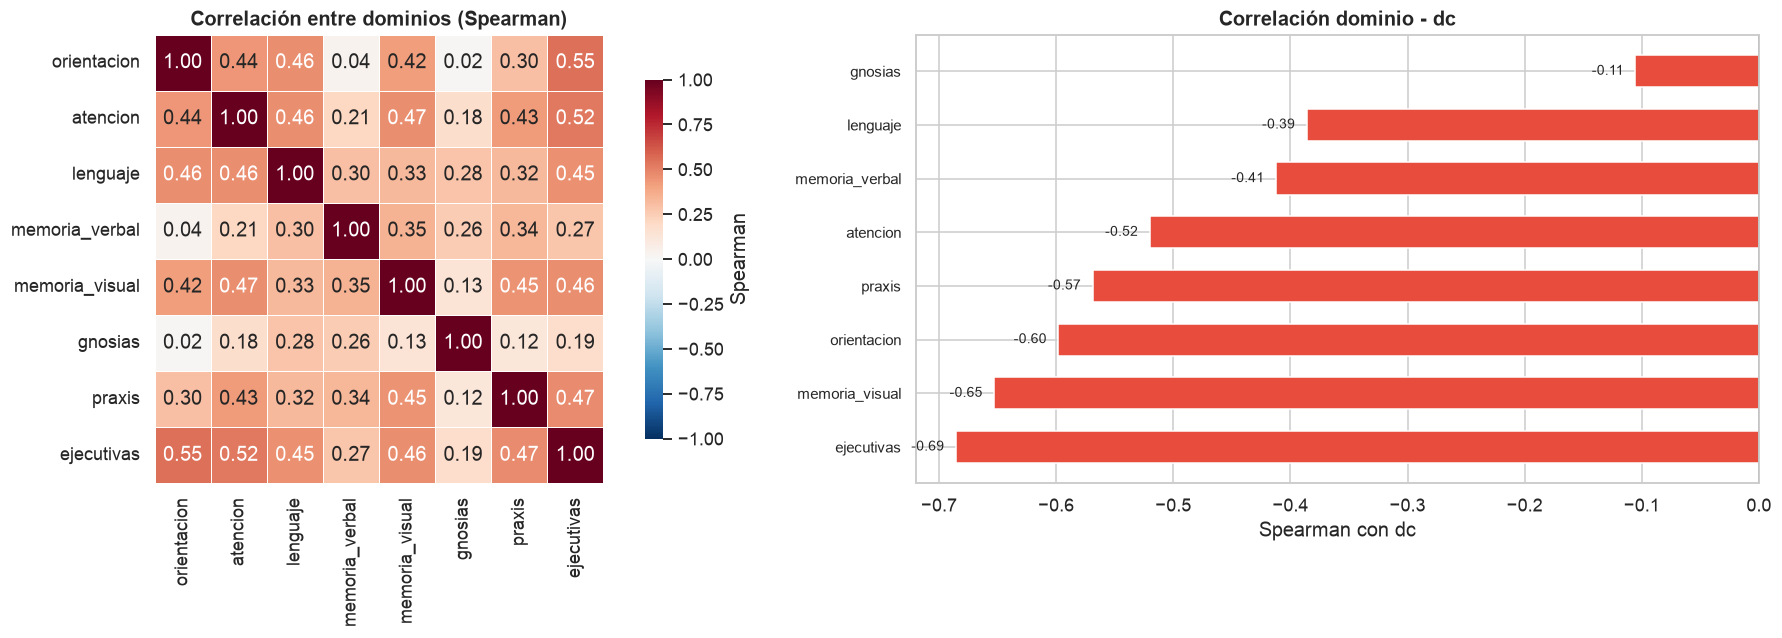

In [22]:
#Gráficos de correlaciones

fig, axes = plt.subplots(1, 2, figsize=(18, 6), squeeze=False)
ax_left, ax_right = axes[0, 0], axes[0, 1]

# Heatmap entre dominios
corr_dom = df_complete[DOMINIOS_COGNITIVOS].corr(method="spearman")
sns.heatmap(
    corr_dom, ax=ax_left,
    annot=True, fmt=".2f",
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Spearman"},
)
ax_left.set_title("Correlación entre dominios (Spearman)", fontweight="bold")

# Gráfico de Spearmna correlación dominio vs dc
corr_dc = (
    df_complete[DOMINIOS_COGNITIVOS + ["dc"]]
    .corr(method="spearman")[["dc"]]
    .drop("dc")
    .sort_values("dc")
)
dom_names = corr_dc.index.tolist()
rho_vals  = corr_dc["dc"].values.tolist()
y_pos     = list(range(len(dom_names)))
bar_colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in rho_vals]

ax_right.barh(y_pos, rho_vals, color=bar_colors, edgecolor="white", height=0.6)
ax_right.set_yticks(y_pos)
ax_right.set_yticklabels(dom_names, fontsize=10)
ax_right.axvline(0, color="black", linewidth=1.2)
ax_right.set_xlabel("Spearman con dc")
ax_right.set_title("Correlación dominio - dc",
                   fontweight="bold")
for i, v in enumerate(rho_vals):
    offset = 0.01 if v >= 0 else -0.01
    ha     = "left" if v >= 0 else "right"
    ax_right.text(v + offset, i, f"{v:.2f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

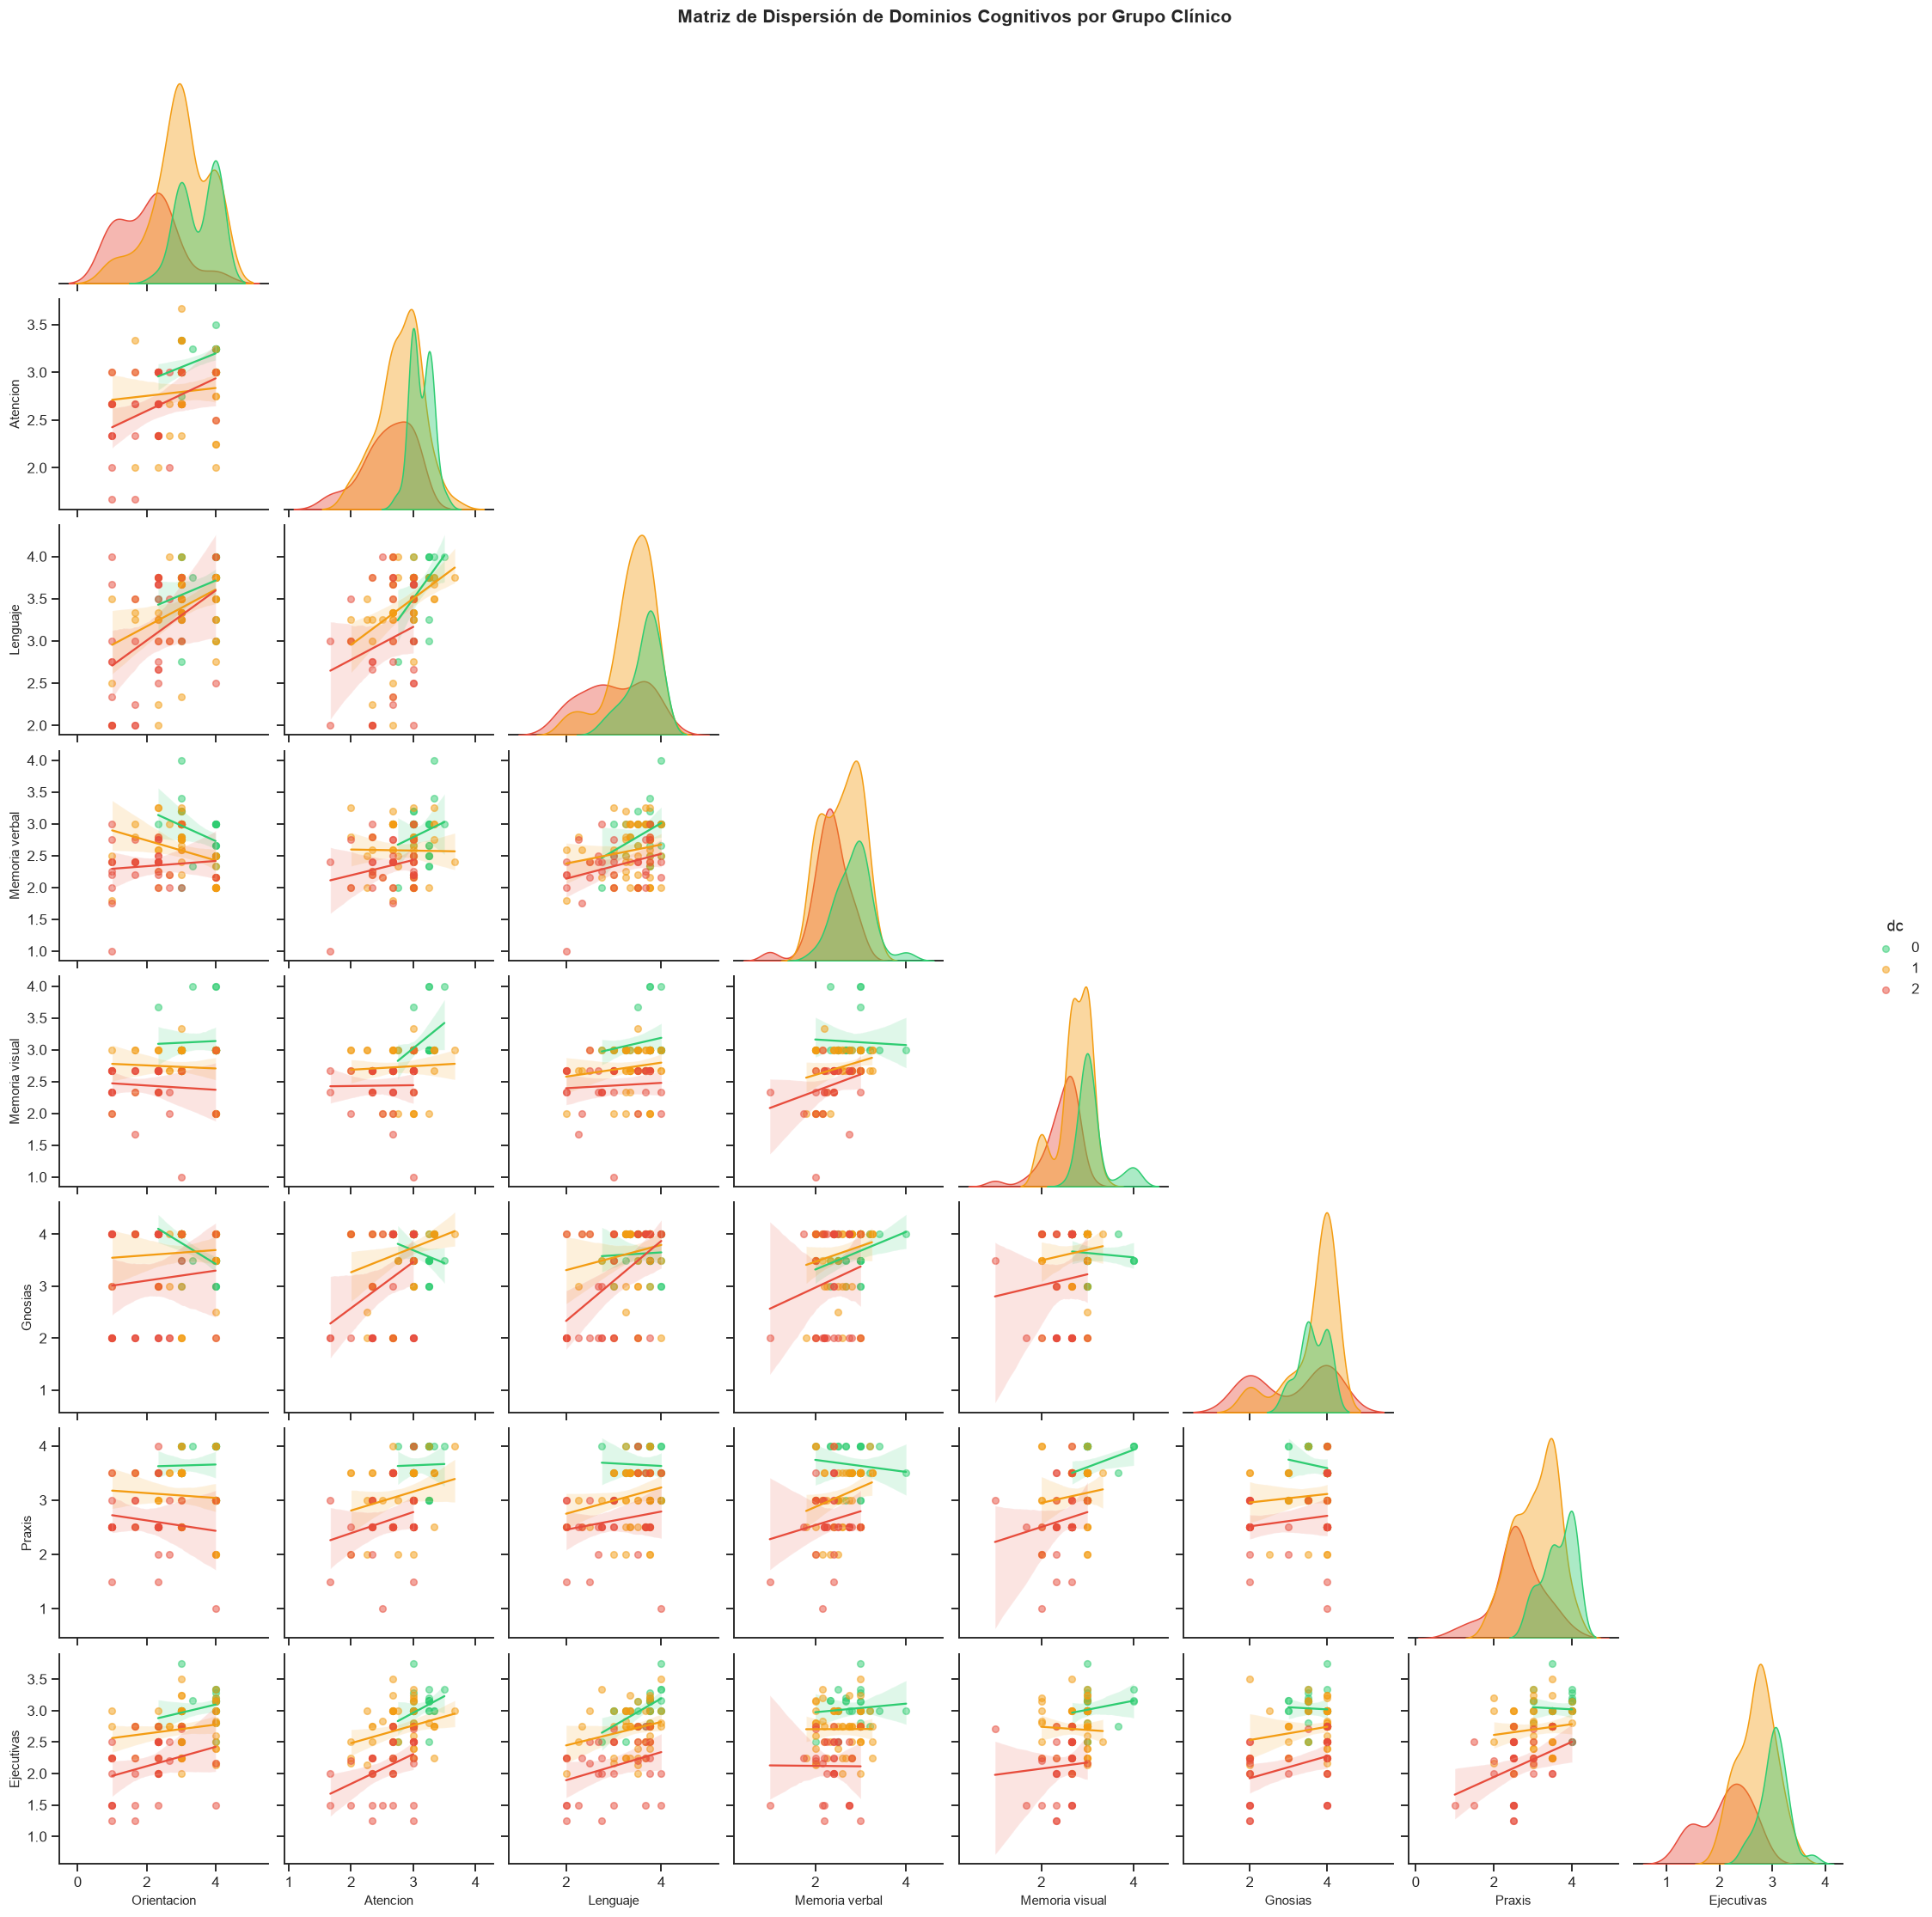

In [32]:

sns.set_theme(style="ticks")

#Pairplot de dominios cognitivos con hue por grupo clínico
g = sns.pairplot(
    data=df_complete[DOMINIOS_COGNITIVOS + ["dc"]],
    hue="dc",
    palette=DC_PALETTE, 
    kind="reg",  
    diag_kind="kde", 
    corner=True,
    plot_kws={
        "scatter_kws": {"alpha": 0.5, "s": 25},
        "line_kws": {"linewidth": 1.5},
    },
    diag_kws={"fill": True, "alpha": 0.4},
)

# Formateo de los ejes y etiquetas para mejorar la legibilidad
for ax in g.axes.flat:
    if ax is not None:
        if ax.get_xlabel():
            ax.set_xlabel(
                ax.get_xlabel().replace("_", " ").capitalize(), fontsize=10
            )
        if ax.get_ylabel():
            ax.set_ylabel(
                ax.get_ylabel().replace("_", " ").capitalize(), fontsize=10
            )

# Titulo
g.figure.suptitle(
    "Matriz de Dispersión de Dominios Cognitivos por Grupo Clínico",
    fontsize=14,
    fontweight="bold",
    y=1.02,  # Eleva un poco el título para que no choque con los gráficos
)

plt.show()

In [37]:
print("Resumén estadistico de los datos por grupo clínico")
print("_" * 100)

rows = []
for dom in DOMINIOS:
    row = {"Dominio": dom}
    for k in DC_ORDER:
        vals = df_complete[df_complete["dc"] == k][dom].dropna()
        lbl  = DC_LABELS[k]
        row[f"{lbl} n"]      = len(vals)
        row[f"{lbl} media"]  = round(vals.mean(), 2) if len(vals) else np.nan
        row[f"{lbl} mediana"]= round(vals.median(), 2) if len(vals) else np.nan
        row[f"{lbl} std"]    = round(vals.std(), 2) if len(vals) else np.nan
    rows.append(row)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print(pd.DataFrame(rows).set_index("Dominio").to_string())


Resumén estadistico de los datos por grupo clínico
____________________________________________________________________________________________________
                Control n  Control media  Control mediana  Control std  DCL n  DCL media  DCL mediana  DCL std  Demencia n  Demencia media  Demencia mediana  Demencia std
Dominio                                                                                                                                                                   
orientacion            27           3.51             4.00         0.54     58       3.00         3.00     0.81          32            2.02              2.33          0.84
atencion               27           3.13             3.00         0.17     58       2.79         2.88     0.35          32            2.60              2.67          0.39
lenguaje               27           3.63             3.75         0.34     58       3.39         3.50     0.46          32            3.01              3.00        